<a href="https://colab.research.google.com/github/nimashanishadini/Final_Research_ModeCreate/blob/main/Final_Model_Train(2_Classes).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

# 1. IMPORT LIBRARIES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

In [ ]:
# 2. UPLOAD DATASET
from google.colab import files
uploaded = files.upload()

file_name = list(uploaded.keys())[0]
df = pd.read_csv(file_name)

print("Original shape:", df.shape)

Saving research_dataset_4.csv to research_dataset_4 (1).csv
Original shape: (210, 23)


In [ ]:
# 3. CLEAN COLUMN NAMES
df.columns = df.columns.astype(str).str.strip()
df = df.loc[:, ~df.columns.duplicated()].copy()

print("\nColumns:")
for c in df.columns:
    print(c)


Columns:
Timestamp
Age Group
Gender
Faculty / Field of Study
Year of Study
Average daily screen time for academic purposes
Academic activities performed using screens
Typical time period of academic screen use
I feel mentally fatigued after prolonged academic screen use
Average daily non-academic screen time
Non-academic screen activities
Frequency of non-academic screen use before sleep
I find it difficult to limit non-academic screen use
Average sleep duration per night
Difficulty falling asleep
I feel rested upon waking up in the morning
Screen use negatively affects my sleep quality
I feel stressed due to academic and daily responsibilities
I feel anxious when I am unable to access my phone or digital devices
Frequency of mental exhaustion
I am satisfied with my overall mental well-being
Overall self-rating of mental wellness
Overall self-rating of sleep quality


In [ ]:
# 4. DROP TIMESTAMP IF EXISTS
if "Timestamp" in df.columns:
    df = df.drop(columns=["Timestamp"])


In [ ]:
# 5. RENAME IMPORTANT COLUMNS
rename_map = {
    "Age Group": "age_group",
    "Gender": "gender",
    "Faculty / Field of Study": "faculty",
    "Year of Study": "year_of_study",
    "Average daily screen time for academic purposes": "academic_screen_time",
    "Academic activities performed using screens": "academic_activities",
    "Typical time period of academic screen use": "academic_time_period",
    "I feel mentally fatigued after prolonged academic screen use": "mental_fatigue_academic",
    "Average daily non-academic screen time": "non_academic_screen_time",
    "Non-academic screen activities": "non_academic_activities",
    "Frequency of non-academic screen use before sleep": "before_sleep_use",
    "I find it difficult to limit non-academic screen use": "limit_non_academic_use",
    "Average sleep duration per night": "sleep_duration",
    "Difficulty falling asleep": "difficulty_falling_asleep",
    "I feel rested upon waking up in the morning": "rested_morning",
    "Screen use negatively affects my sleep quality": "screen_affects_sleep",
    "I feel stressed due to academic and daily responsibilities": "stress_level",
    "I feel anxious when I am unable to access my phone or digital devices": "device_anxiety",
    "Frequency of mental exhaustion": "mental_exhaustion_freq",
    "I am satisfied with my overall mental well-being": "mental_wellbeing_satisfaction",
    "Overall self-rating of mental wellness": "mental",
    "Overall self-rating of sleep quality": "sleep"
}

df = df.rename(columns=rename_map)

In [ ]:
# 6. STANDARDIZE STRING VALUES
for col in df.columns:
    if df[col].dtype == "object":
        df[col] = df[col].astype(str).str.strip()

In [ ]:
# 7. MAP TARGETS (ORIGINAL 5 CLASS)
rating_map = {
    "Poor": 0,
    "Fair": 1,
    "Good": 2,
    "Very Good": 3,
    "Excellent": 4
}

if "mental" in df.columns:
    df["mental"] = df["mental"].replace(rating_map)

if "sleep" in df.columns:
    df["sleep"] = df["sleep"].replace(rating_map)

/tmp/ipykernel_7920/1412300349.py:11: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["mental"] = df["mental"].replace(rating_map)
/tmp/ipykernel_7920/1412300349.py:14: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["sleep"] = df["sleep"].replace(rating_map)


In [ ]:
# 8. MAP SOME COMMON QUESTIONNAIRE VALUES

screen_time_map = {
    "Less than 2 hours": 1,
    "2–4 hours": 2,
    "4–6 hours": 3,
    "More than 6 hours": 4,
    "2-4 hours": 2,
    "4-6 hours": 3
}

sleep_duration_map = {
    "Less than 5 hours": 1,
    "5–6 hours": 2,
    "6–7 hours": 3,
    "More than 7 hours": 4,
    "5-6 hours": 2,
    "6-7 hours": 3
}

freq_map = {
    "Never": 0,
    "Rarely": 1,
    "Sometimes": 2,
    "Often": 3,
    "Always": 4
}

agreement_map = {
    "Strongly Disagree": 1,
    "Disagree": 2,
    "Neutral": 3,
    "Agree": 4,
    "Strongly Agree": 5
}

stress_map = {
    "Low": 1,
    "Medium": 2,
    "High": 3,
    "Very High": 4
}

if "academic_screen_time" in df.columns:
    df["academic_screen_time"] = df["academic_screen_time"].replace(screen_time_map)

if "non_academic_screen_time" in df.columns:
    df["non_academic_screen_time"] = df["non_academic_screen_time"].replace(screen_time_map)

if "sleep_duration" in df.columns:
    df["sleep_duration"] = df["sleep_duration"].replace(sleep_duration_map)

for col in [
    "before_sleep_use",
    "difficulty_falling_asleep",
    "mental_exhaustion_freq",
    "limit_non_academic_use"
]:
    if col in df.columns:
        df[col] = df[col].replace(freq_map)

for col in [
    "mental_fatigue_academic",
    "rested_morning",
    "screen_affects_sleep",
    "device_anxiety",
    "mental_wellbeing_satisfaction"
]:
    if col in df.columns:
        df[col] = df[col].replace(freq_map)
        df[col] = df[col].replace(agreement_map)

if "stress_level" in df.columns:
    df["stress_level"] = df["stress_level"].replace(stress_map)
    df["stress_level"] = df["stress_level"].replace(freq_map)
    df["stress_level"] = df["stress_level"].replace(agreement_map)

/tmp/ipykernel_7920/2572985063.py:45: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["academic_screen_time"] = df["academic_screen_time"].replace(screen_time_map)
/tmp/ipykernel_7920/2572985063.py:48: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["non_academic_screen_time"] = df["non_academic_screen_time"].replace(screen_time_map)
/tmp/ipykernel_7920/2572985063.py:51: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infe

In [ ]:
# 9. CONVERT TO 2-CLASS TARGETS
#    0,1,2 -> 0
#    3,4   -> 1

df["mental_2"] = df["mental"].apply(lambda x: 0 if pd.notna(x) and x <= 2 else 1)
df["sleep_2"] = df["sleep"].apply(lambda x: 0 if pd.notna(x) and x <= 2 else 1)

In [ ]:
# 10. MULTI-SELECT COLUMNS -> ONE HOT ENCODING

multi_select_cols = [
    "academic_activities",
    "academic_time_period",
    "non_academic_activities"
]

for col in multi_select_cols:
    if col in df.columns:
        temp = df[col].fillna("").astype(str)
        dummies = temp.str.get_dummies(sep=",")
        dummies.columns = [
            f"{col}_{str(x).strip().replace(' ', '_').replace('/', '_').replace('-', '_')}"
            for x in dummies.columns
        ]
        df = pd.concat([df, dummies], axis=1)
        df = df.drop(columns=[col])

df = df.loc[:, ~df.columns.duplicated()].copy()

In [ ]:
# 11. ENCODE REMAINING OBJECT COLUMNS

for col in df.columns:
    if df[col].dtype == "object":
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col].astype(str))

In [ ]:
# 12. FORCE NUMERIC + HANDLE MISSING VALUES

for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors="ignore")

for col in df.columns:
    if pd.api.types.is_numeric_dtype(df[col]) and df[col].isna().sum() > 0:
        df[col] = df[col].fillna(df[col].median())

/tmp/ipykernel_7920/3713100871.py:4: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df[col] = pd.to_numeric(df[col], errors="ignore")


In [ ]:
# 13. FEATURE ENGINEERING

if "academic_screen_time" in df.columns and "non_academic_screen_time" in df.columns:
    df["total_screen_time"] = df["academic_screen_time"] + df["non_academic_screen_time"]

if "before_sleep_use" in df.columns and "difficulty_falling_asleep" in df.columns:
    df["night_risk"] = df["before_sleep_use"] + df["difficulty_falling_asleep"]

if "stress_level" in df.columns and "device_anxiety" in df.columns and "mental_exhaustion_freq" in df.columns:
    df["mental_risk"] = df["stress_level"] + df["device_anxiety"] + df["mental_exhaustion_freq"]

if "screen_affects_sleep" in df.columns and "rested_morning" in df.columns:
    df["sleep_risk"] = df["screen_affects_sleep"] + (5 - df["rested_morning"])

In [ ]:
# 14. PREPARE FEATURES / TARGETS

drop_cols = ["mental", "sleep", "mental_2", "sleep_2"]
feature_cols = [c for c in df.columns if c not in drop_cols]

X = df[feature_cols].copy()
y_mental = df["mental_2"].copy()
y_sleep = df["sleep_2"].copy()

print("\nFeature shape:", X.shape)
print("Mental target distribution:")
print(y_mental.value_counts())
print("\nSleep target distribution:")
print(y_sleep.value_counts())


Feature shape: (210, 36)
Mental target distribution:
mental_2
0    170
1     40
Name: count, dtype: int64

Sleep target distribution:
sleep_2
0    171
1     39
Name: count, dtype: int64


In [ ]:
# 15. SCALE FEATURES

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
# 16. TRAIN TEST SPLIT

X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_scaled, y_mental, test_size=0.2, random_state=42, stratify=y_mental
)

X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_scaled, y_sleep, test_size=0.2, random_state=42, stratify=y_sleep
)

# keep original row indexes for prediction tables
X_train_idx_m, X_test_idx_m = train_test_split(
    df.index, test_size=0.2, random_state=42, stratify=y_mental
)

X_train_idx_s, X_test_idx_s = train_test_split(
    df.index, test_size=0.2, random_state=42, stratify=y_sleep
)

In [55]:
# 17. DEFINE MODELS

models = {
    "Random Forest": RandomForestClassifier(
        n_estimators=400,
        class_weight="balanced",
        random_state=42
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=200,
        random_state=42
    ),
    "Logistic Regression": LogisticRegression(
        max_iter=2000,
        class_weight="balanced"
    ),
    "SVM": SVC(
        class_weight="balanced",
        probability=True
    )
}


In [56]:
# 18. IMPORT EXTRA METRICS

from sklearn.metrics import (
    precision_score,
    recall_score,
    roc_auc_score
)


In [57]:
# 19. TRAIN + EVALUATE FUNCTION

def run_models(X_train, X_test, y_train, y_test, task_name):
    results = []
    fitted_models = {}
    predictions_dict = {}

    print(f"\n==================== {task_name} ====================")

    for model_name, model in models.items():
        model.fit(X_train, y_train)
        pred = model.predict(X_test)

        # probability for ROC-AUC
        if hasattr(model, "predict_proba"):
            y_prob = model.predict_proba(X_test)[:, 1]
        else:
            y_prob = None

        acc = accuracy_score(y_test, pred)
        prec = precision_score(y_test, pred, zero_division=0)
        rec = recall_score(y_test, pred, zero_division=0)
        f1 = f1_score(y_test, pred, zero_division=0)

        if y_prob is not None:
            roc_auc = roc_auc_score(y_test, y_prob)
        else:
            roc_auc = np.nan

        results.append({
            "Model": model_name,
            "Accuracy": acc,
            "Precision": prec,
            "Recall": rec,
            "F1-score": f1,
            "ROC-AUC": roc_auc
        })

        fitted_models[model_name] = model
        predictions_dict[model_name] = pred

        print(f"\n{model_name}")
        print("Accuracy :", round(acc, 4))
        print("Precision:", round(prec, 4))
        print("Recall   :", round(rec, 4))
        print("F1-score :", round(f1, 4))
        if pd.notna(roc_auc):
            print("ROC-AUC  :", round(roc_auc, 4))
        else:
            print("ROC-AUC  : Not available")
        print("\nClassification Report:")
        print(classification_report(y_test, pred, zero_division=0))

    results_df = pd.DataFrame(results).sort_values(by="Accuracy", ascending=False).reset_index(drop=True)
    return results_df, fitted_models, predictions_dict

In [58]:
# 20. RUN MODELS

mental_results, mental_models, mental_preds = run_models(
    X_train_m, X_test_m, y_train_m, y_test_m, "MENTAL WELLNESS (2-CLASS)"
)

sleep_results, sleep_models, sleep_preds = run_models(
    X_train_s, X_test_s, y_train_s, y_test_s, "SLEEP QUALITY (2-CLASS)"
)


==================== MENTAL WELLNESS (2-CLASS) ====================

Random Forest
Accuracy : 0.8095
Precision: 0.5
Recall   : 0.125
F1-score : 0.2
ROC-AUC  : 0.6783

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.97      0.89        34
           1       0.50      0.12      0.20         8

    accuracy                           0.81        42
   macro avg       0.66      0.55      0.55        42
weighted avg       0.76      0.81      0.76        42


Gradient Boosting
Accuracy : 0.6905
Precision: 0.1429
Recall   : 0.125
F1-score : 0.1333
ROC-AUC  : 0.614

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.82      0.81        34
           1       0.14      0.12      0.13         8

    accuracy                           0.69        42
   macro avg       0.47      0.47      0.47        42
weighted avg       0.67      0.69      0.68        42


Logistic Regression
Acc

In [69]:
# ============================================================
# 21. RESULT TABLES IN COLAB (2-COLOR STYLE)
# ============================================================

def two_color_table(df):
    return df.style \
        .format({
            "Accuracy": "{:.4f}",
            "Precision": "{:.4f}",
            "Recall": "{:.4f}",
            "F1-score": "{:.4f}",
            "ROC-AUC": "{:.4f}"
        }) \
        .background_gradient(
            subset=["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"],
            cmap="Blues"   # change to "Greens" if needed
        ) \
        .set_properties(**{
            "border": "1px solid black",
            "text-align": "center"
        }) \
        .set_table_styles([
            {
                'selector': 'th',
                'props': [
                    ('background-color', '#2c3e50'),
                    ('color', 'white'),
                    ('font-weight', 'bold'),
                    ('text-align', 'center')
                ]
            }
        ])

print("\n========== FINAL RESULT TABLES ==========")

print("\nMental Wellness Performance Table")
display(two_color_table(mental_results))

print("\nSleep Quality Performance Table")
display(two_color_table(sleep_results))


========== FINAL RESULT TABLES ==========

Mental Wellness Performance Table


,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Random Forest,0.8095,0.5000,0.1250,0.2000,0.6783
1,Logistic Regression,0.7381,0.2857,0.2500,0.2667,0.7757
2,SVM,0.7143,0.2500,0.2500,0.2500,0.6838
3,Gradient Boosting,0.6905,0.1429,0.1250,0.1333,0.6140



Sleep Quality Performance Table


,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Random Forest,0.8333,0.6667,0.2500,0.3636,0.6434
1,Gradient Boosting,0.8333,0.5714,0.5000,0.5333,0.7353
2,SVM,0.8095,0.5000,0.5000,0.5000,0.6875
3,Logistic Regression,0.7381,0.3846,0.6250,0.4762,0.7243


In [60]:
# 22. SAVE RESULT TABLES

mental_results.to_csv("mental_performance_metrics.csv", index=False)
sleep_results.to_csv("sleep_performance_metrics.csv", index=False)

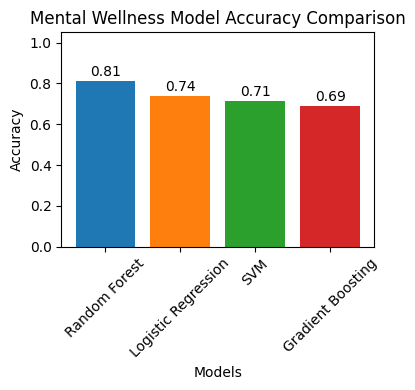

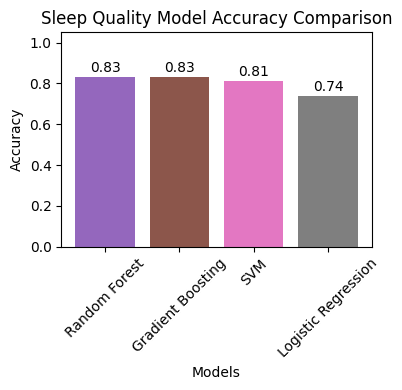

In [63]:
# 23. ACCURACY COMPARISON BAR CHARTS (DIFFERENT COLORS)

mental_colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]
sleep_colors = ["#9467bd", "#8c564b", "#e377c2", "#7f7f7f"]

plt.figure(figsize=(4, 4))
bars = plt.bar(mental_results["Model"], mental_results["Accuracy"], color=mental_colors[:len(mental_results)])
plt.xticks(rotation=45)
plt.ylabel("Accuracy")
plt.xlabel("Models")
plt.title("Mental Wellness Model Accuracy Comparison")
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.01, f"{yval:.2f}", ha='center', va='bottom')
plt.ylim(0, 1.05)
plt.tight_layout()
plt.show()

plt.figure(figsize=(4, 4))
bars = plt.bar(sleep_results["Model"], sleep_results["Accuracy"], color=sleep_colors[:len(sleep_results)])
plt.xticks(rotation=45)
plt.ylabel("Accuracy")
plt.xlabel("Models")
plt.title("Sleep Quality Model Accuracy Comparison")
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.01, f"{yval:.2f}", ha='center', va='bottom')
plt.ylim(0, 1.05)
plt.tight_layout()
plt.show()

In [64]:
# 24. BEST MODELS

best_mental_name = mental_results.iloc[0]["Model"]
best_sleep_name = sleep_results.iloc[0]["Model"]

best_mental_model = mental_models[best_mental_name]
best_sleep_model = sleep_models[best_sleep_name]

mental_pred_best = mental_preds[best_mental_name]
sleep_pred_best = sleep_preds[best_sleep_name]

print("\nBest Mental Model:", best_mental_name)
print("Best Sleep Model :", best_sleep_name)


Best Mental Model: Random Forest
Best Sleep Model : Random Forest


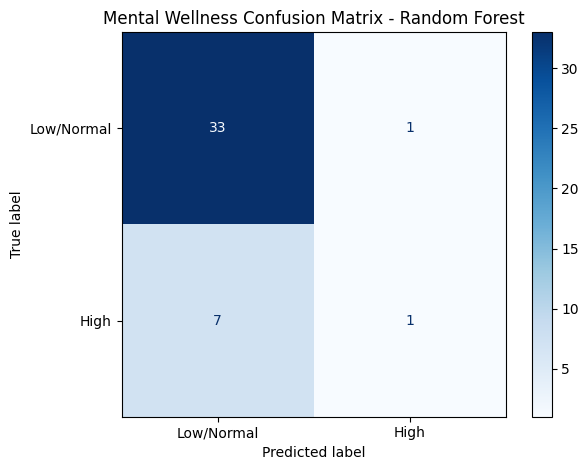

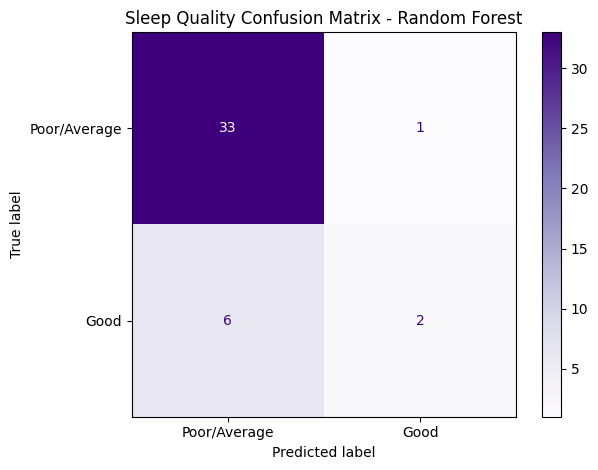

In [65]:
# 25. CONFUSION MATRIX DIAGRAMS

cm_mental = confusion_matrix(y_test_m, mental_pred_best)
disp_mental = ConfusionMatrixDisplay(confusion_matrix=cm_mental, display_labels=["Low/Normal", "High"])
disp_mental.plot(cmap="Blues")
plt.title(f"Mental Wellness Confusion Matrix - {best_mental_name}")
plt.tight_layout()
plt.show()

cm_sleep = confusion_matrix(y_test_s, sleep_pred_best)
disp_sleep = ConfusionMatrixDisplay(confusion_matrix=cm_sleep, display_labels=["Poor/Average", "Good"])
disp_sleep.plot(cmap="Purples")
plt.title(f"Sleep Quality Confusion Matrix - {best_sleep_name}")
plt.tight_layout()
plt.show()


Top 15 Important Features - Mental Wellness


,Feature,Importance
10,difficulty_falling_asleep,0.065653
33,night_risk,0.054016
12,screen_affects_sleep,0.049859
4,academic_screen_time,0.046349
34,mental_risk,0.044308
11,rested_morning,0.043731
32,total_screen_time,0.042913
5,mental_fatigue_academic,0.042814
35,sleep_risk,0.037597
8,limit_non_academic_use,0.034433


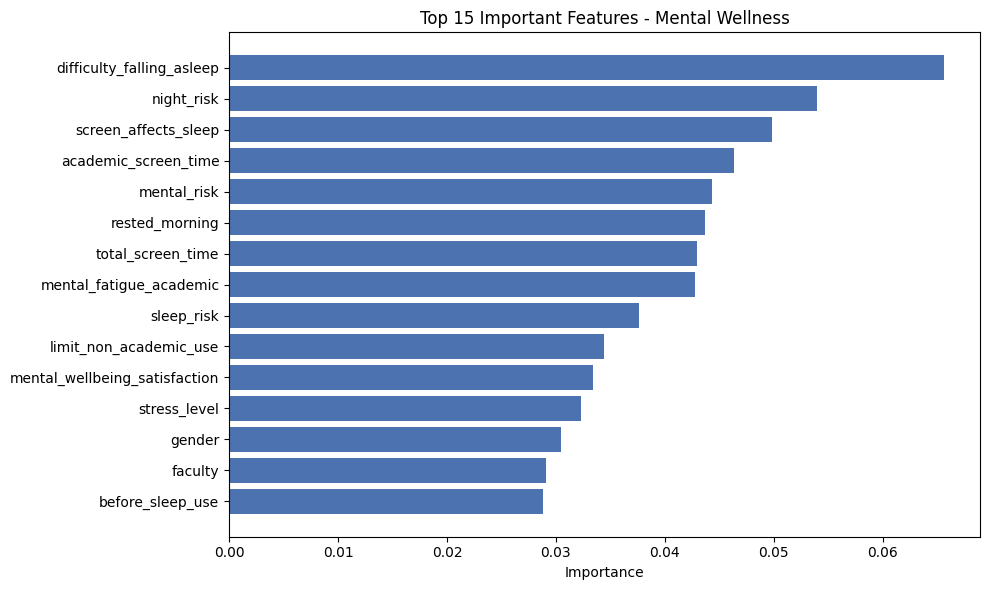


Top 15 Important Features - Sleep Quality


,Feature,Importance
10,difficulty_falling_asleep,0.065653
33,night_risk,0.054016
12,screen_affects_sleep,0.049859
4,academic_screen_time,0.046349
34,mental_risk,0.044308
11,rested_morning,0.043731
32,total_screen_time,0.042913
5,mental_fatigue_academic,0.042814
35,sleep_risk,0.037597
8,limit_non_academic_use,0.034433


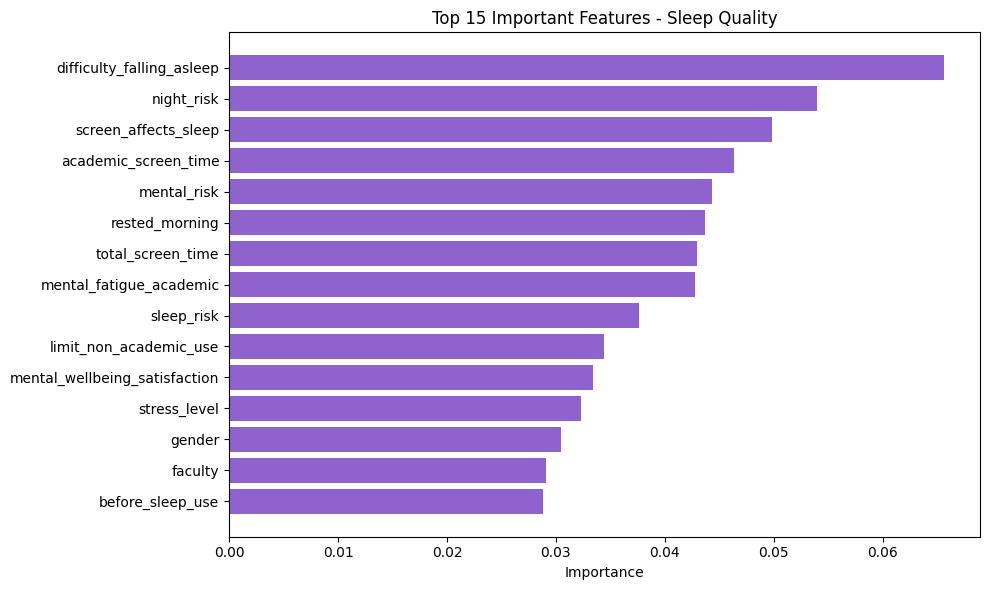

In [66]:
# 26. FEATURE IMPORTANCE (RANDOM FOREST)

if "Random Forest" in mental_models:
    rf_m = mental_models["Random Forest"]
    mental_importance = pd.DataFrame({
        "Feature": feature_cols,
        "Importance": rf_m.feature_importances_
    }).sort_values(by="Importance", ascending=False).head(15)

    print("\nTop 15 Important Features - Mental Wellness")
    display(mental_importance)

    plt.figure(figsize=(10, 6))
    plt.barh(mental_importance["Feature"], mental_importance["Importance"], color="#4C72B0")
    plt.gca().invert_yaxis()
    plt.title("Top 15 Important Features - Mental Wellness")
    plt.xlabel("Importance")
    plt.tight_layout()
    plt.show()

if "Random Forest" in sleep_models:
    rf_s = sleep_models["Random Forest"]
    sleep_importance = pd.DataFrame({
        "Feature": feature_cols,
        "Importance": rf_s.feature_importances_
    }).sort_values(by="Importance", ascending=False).head(15)

    print("\nTop 15 Important Features - Sleep Quality")
    display(sleep_importance)

    plt.figure(figsize=(10, 6))
    plt.barh(sleep_importance["Feature"], sleep_importance["Importance"], color="#8E63CE")
    plt.gca().invert_yaxis()
    plt.title("Top 15 Important Features - Sleep Quality")
    plt.xlabel("Importance")
    plt.tight_layout()
    plt.show()

In [67]:
# 27. PREDICTION TABLES

mental_prediction_table = pd.DataFrame({
    "Row_Index": X_test_idx_m,
    "Actual_Mental": y_test_m.values,
    "Predicted_Mental": mental_pred_best
})
mental_prediction_table["Correct"] = (
    mental_prediction_table["Actual_Mental"] == mental_prediction_table["Predicted_Mental"]
)

sleep_prediction_table = pd.DataFrame({
    "Row_Index": X_test_idx_s,
    "Actual_Sleep": y_test_s.values,
    "Predicted_Sleep": sleep_pred_best
})
sleep_prediction_table["Correct"] = (
    sleep_prediction_table["Actual_Sleep"] == sleep_prediction_table["Predicted_Sleep"]
)

mental_label_map = {0: "Low/Normal", 1: "High"}
sleep_label_map = {0: "Poor/Average", 1: "Good"}

mental_prediction_table["Actual_Label"] = mental_prediction_table["Actual_Mental"].map(mental_label_map)
mental_prediction_table["Predicted_Label"] = mental_prediction_table["Predicted_Mental"].map(mental_label_map)

sleep_prediction_table["Actual_Label"] = sleep_prediction_table["Actual_Sleep"].map(sleep_label_map)
sleep_prediction_table["Predicted_Label"] = sleep_prediction_table["Predicted_Sleep"].map(sleep_label_map)

print("\nMental Prediction Table (first 20 rows)")
display(mental_prediction_table.head(20))

print("\nSleep Prediction Table (first 20 rows)")
display(sleep_prediction_table.head(20))


Mental Prediction Table (first 20 rows)


,Row_Index,Actual_Mental,Predicted_Mental,Correct,Actual_Label,Predicted_Label
0,160,0,0,True,Low/Normal,Low/Normal
1,94,0,0,True,Low/Normal,Low/Normal
2,43,1,0,False,High,Low/Normal
3,191,0,0,True,Low/Normal,Low/Normal
4,86,0,0,True,Low/Normal,Low/Normal
5,65,0,0,True,Low/Normal,Low/Normal
6,71,0,0,True,Low/Normal,Low/Normal
7,155,0,0,True,Low/Normal,Low/Normal
8,74,0,0,True,Low/Normal,Low/Normal
9,26,1,0,False,High,Low/Normal



Sleep Prediction Table (first 20 rows)


,Row_Index,Actual_Sleep,Predicted_Sleep,Correct,Actual_Label,Predicted_Label
0,158,0,0,True,Poor/Average,Poor/Average
1,87,0,0,True,Poor/Average,Poor/Average
2,113,1,0,False,Good,Poor/Average
3,189,0,0,True,Poor/Average,Poor/Average
4,78,0,0,True,Poor/Average,Poor/Average
5,59,0,0,True,Poor/Average,Poor/Average
6,63,0,0,True,Poor/Average,Poor/Average
7,153,0,0,True,Poor/Average,Poor/Average
8,65,0,0,True,Poor/Average,Poor/Average
9,121,1,1,True,Good,Good


In [68]:
# 28. SAVE PREDICTION TABLES

mental_prediction_table.to_csv("mental_prediction_table.csv", index=False)
sleep_prediction_table.to_csv("sleep_prediction_table.csv", index=False)

print("\nSaved files:")
print("- mental_performance_metrics.csv")
print("- sleep_performance_metrics.csv")
print("- mental_prediction_table.csv")
print("- sleep_prediction_table.csv")


Saved files:
- mental_performance_metrics.csv
- sleep_performance_metrics.csv
- mental_prediction_table.csv
- sleep_prediction_table.csv
